# Week 3 Lab 3B: Neural Network and Decision Tree Classification with the Iris Dataset

This notebook demonstrates **classification** using the clean Iris dataset.

In this notebook, we will:

1. Load the clean Iris dataset.
2. Select input columns and a target column.
3. Train a simple neural network with **1 hidden layer and 6 neurons**.
4. Train a Decision Tree using the same data.
5. Compare the results.
6. Expand the neural network to **2 hidden layers** and compare again.

The purpose is to understand the workflow and model comparison, not to create the most advanced model.

The same workflow can be demonstrated in Orange

## Step 1: Import the tools we need

These libraries help us load the data, split it into training/validation/test sets, train models, and evaluate results.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

## Step 2: Load the clean Iris dataset

The Iris dataset is already clean. It includes four numerical measurements and one target label called species.

The target label is what we want the model to predict.

You have two options to import/get the file into the notebook

Upload iris.csv from your desktop
Get it from a URL directly to the notebook
Click the run button ▶️ on the left side for eaither option 1 or 2 to run the cell.

Once you complete the step you should be able to see the first few rows of the dataset.

In [ ]:
# Option (1)
from google.colab import files
import pandas as pd
uploaded = files.upload()
df = pd.read_csv("iris.csv")
df.head()

In [5]:

# Option (2) No need to execute this if option (1) worked
import pandas as pd
url = "https://raw.githubusercontent.com/UConnARIAL/NRE5615_EnviroAI_Code_and_Data/main/data/iris.csv"
df = pd.read_csv(url)
df.head()

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,iris_species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Step 3: View the available columns

This step is similar to inspecting the dataset before using **Select Columns** in Orange.

In [6]:
print("Available columns:")
for col in df.columns:
    print("-", col)

Available columns:
- sepal_length_cm
- sepal_width_cm
- petal_length_cm
- petal_width_cm
- iris_species


## Step 4: Select input columns and the target column

This is similar to using **Select Columns** in Orange.

- Input columns are the measurements used by the model.
- The target column is the class label the model tries to predict.

You can change `selected_features` later to see how feature selection affects model performance.

In [11]:
selected_features = [
    "sepal_length_cm",
    "sepal_width_cm",
    "petal_length_cm",
    "petal_width_cm"
]

target_column = "iris_species"

X = df[selected_features].copy()
y = df[target_column].copy()

print("Input features:")
display(X.head())

print("Target labels:")
display(y.head())

class_names = sorted(y.unique())
print(class_names)

Input features:


,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


Target labels:


,iris_species
0,setosa
1,setosa
2,setosa
3,setosa
4,setosa


['setosa', 'versicolor', 'virginica']


## Step 5: Split the data into training, validation, and test sets

We use:

- **Training data** to teach the model.
- **Validation data** to check model performance while comparing models.
- **Test data** as a final check on data the model has not seen.

This notebook uses a 60% training, 20% validation, and 20% test split.

In Orange, a similar comparison can be done using **Test & Score**.

In [34]:
# First split: keep 20% as the final test set
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Second split: split the remaining 80% into 60% training and 20% validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.25,
    random_state=42,
    stratify=y_train_val
)

print("Training rows:", len(X_train))
print("Validation rows:", len(X_val))
print("Test rows:", len(X_test))

# Check whether validation and test sets share any rows
overlap = set(X_val.index).intersection(set(X_test.index))

print("Number of overlapping rows between validation and test:", len(overlap))

Training rows: 90
Validation rows: 30
Test rows: 30
Number of overlapping rows between validation and test: 0


## Step 6: Create a helper function to evaluate models

This function calculates training, validation, and test accuracy. It also displays a confusion matrix for the test set.

In [13]:
def evaluate_model(model, model_name):
    """
    This function trains a model and evaluates it.

    It shows:
    1. Training accuracy
    2. Validation accuracy
    3. Test accuracy
    4. Classification report
    5. Confusion matrix
    """

    # Step 1: Train the model using the training data
    model.fit(X_train, y_train)

    # Step 2: Use the trained model to make predictions
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)

    # Step 3: Calculate accuracy for each dataset
    train_accuracy = accuracy_score(y_train, y_train_pred)
    validation_accuracy = accuracy_score(y_val, y_val_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    # Step 4: Print the accuracy results
    print("Model:", model_name)
    print("Training accuracy:", round(train_accuracy, 3))
    print("Validation accuracy:", round(validation_accuracy, 3))
    print("Test accuracy:", round(test_accuracy, 3))

    # Step 5: Print a classification report for the test data
    print()
    print("Classification report for test data:")
    print(
        classification_report(
            y_test,
            y_test_pred,
            labels=class_names,
            target_names=class_names
        )
    )

    # Step 6: Make and show the confusion matrix
    confusion_mat = confusion_matrix(
        y_test,
        y_test_pred,
        labels=class_names
    )

    display = ConfusionMatrixDisplay(
        confusion_matrix=confusion_mat,
        display_labels=class_names
    )

    display.plot()
    plt.title(model_name + " - Test Confusion Matrix")
    plt.show()

    # Step 7: Save the results so we can compare models later
    results = {
        "Model": model_name,
        "Training Accuracy": train_accuracy,
        "Validation Accuracy": validation_accuracy,
        "Test Accuracy": test_accuracy
    }

    return results

## Step 7: Train a simple neural network

The first neural network has:

- 1 hidden layer
- 6 neurons in that hidden layer

The `StandardScaler` helps prepare numerical values for the neural network. This is not a data cleaning step; it only puts the input variables on a similar scale for the model.

Model: Neural Network: 1 hidden layer, 6 neurons
Training accuracy: 0.978
Validation accuracy: 0.9
Test accuracy: 0.9

Classification report for test data:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.89      0.80      0.84        10
   virginica       0.82      0.90      0.86        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



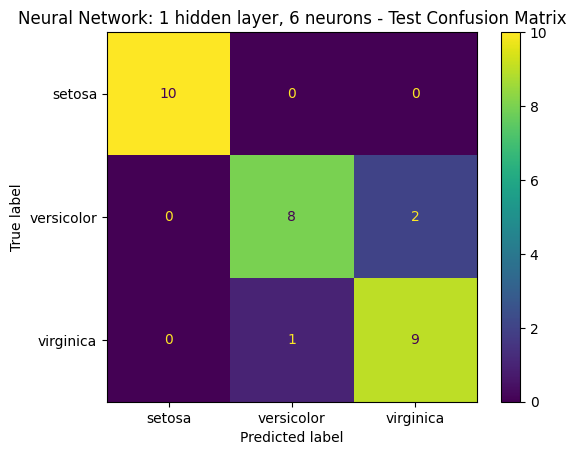

In [14]:
nn_1_layer = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPClassifier(
        hidden_layer_sizes=(6,),
        activation="relu",
        max_iter=2000,
        random_state=42
    ))
])

result_nn_1 = evaluate_model(nn_1_layer, "Neural Network: 1 hidden layer, 6 neurons")

## Step 8: Train a Decision Tree using the same data

The Decision Tree uses the same input columns and target column.

Decision Trees are often easier to explain because they make decisions using a series of splits.

Model: Decision Tree
Training accuracy: 0.989
Validation accuracy: 0.9
Test accuracy: 0.933

Classification report for test data:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



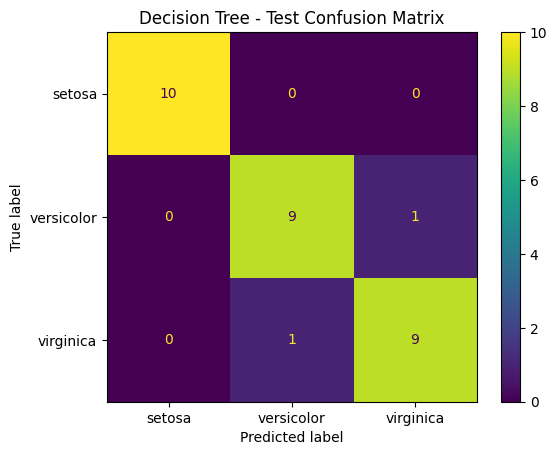

In [15]:
decision_tree = DecisionTreeClassifier(max_depth=3, random_state=42)

result_tree = evaluate_model(decision_tree, "Decision Tree")

## Step 9: View the Decision Tree

This plot shows how the Decision Tree separates the Iris classes.

In Orange, a similar view can be explored using the **Tree Viewer** widget.

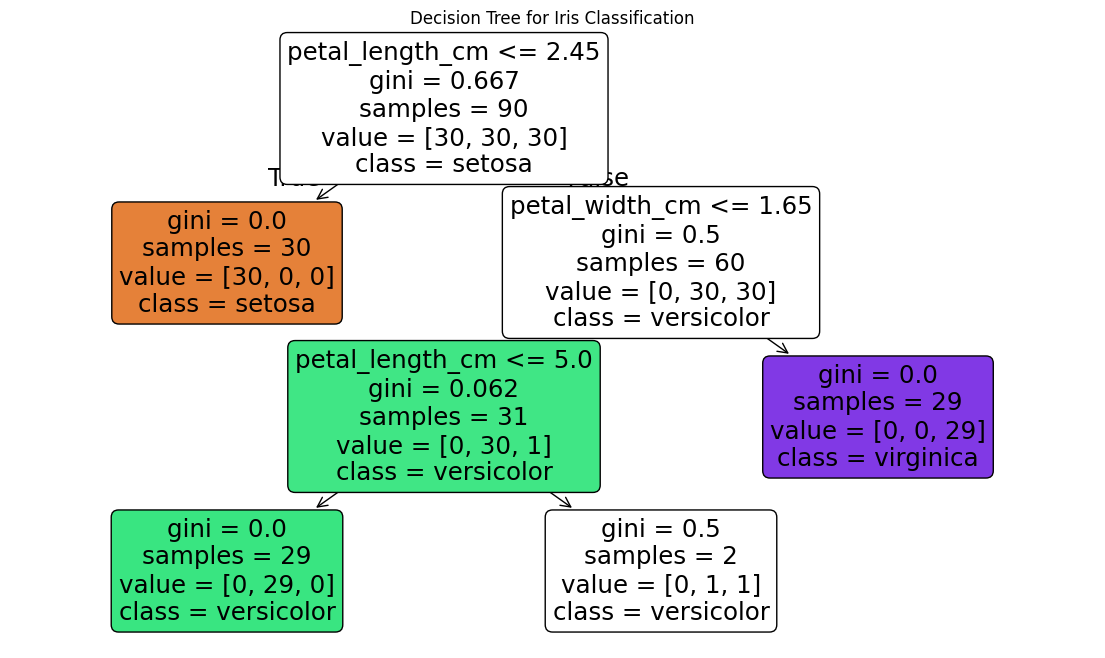

In [18]:
plt.figure(figsize=(14, 8))
plot_tree(
    decision_tree,
    feature_names=selected_features,
    class_names=class_names,
    filled=True,
    rounded=True
)
plt.title("Decision Tree for Iris Classification")
plt.show()

## Step 10: Compare the simple neural network and Decision Tree

Use the table below to compare model performance.

A model with high training accuracy but much lower validation/test accuracy may be overfitting.

In [17]:
comparison_1 = pd.DataFrame([result_nn_1, result_tree])
comparison_1[["Training Accuracy", "Validation Accuracy", "Test Accuracy"]] = comparison_1[["Training Accuracy", "Validation Accuracy", "Test Accuracy"]].round(3)
comparison_1

,Model,Training Accuracy,Validation Accuracy,Test Accuracy
0,"Neural Network: 1 hidden layer, 6 neurons",0.978,0.9,0.900
1,Decision Tree,0.989,0.9,0.933


## Step 11: Train an expanded neural network

Now we add a second hidden layer.

The expanded neural network has:

- Hidden Layer 1: 6 neurons
- Hidden Layer 2: 6 neurons

Adding layers makes the model more complex. This may improve performance, but it may also increase the chance of overfitting.

Model: Neural Network: 2 hidden layers, 6 neurons each
Training accuracy: 0.978
Validation accuracy: 0.933
Test accuracy: 0.933

Classification report for test data:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



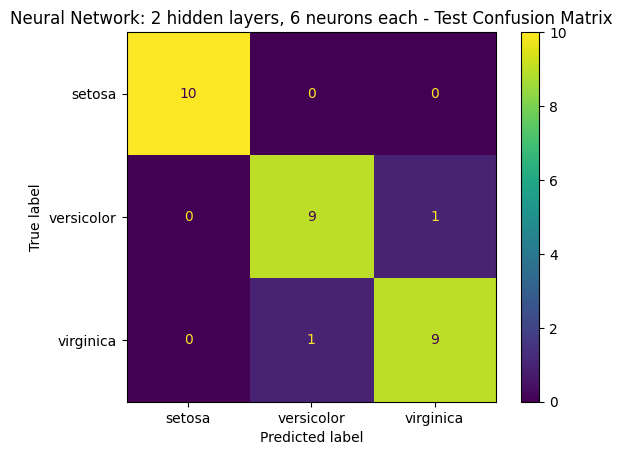

In [35]:
nn_2_layers = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPClassifier(
        hidden_layer_sizes=(6,6),
        activation="relu",
        max_iter=2000,
        random_state=42
    ))
])

result_nn_2 = evaluate_model(nn_2_layers, "Neural Network: 2 hidden layers, 6 neurons each")

## Step 12: Compare the two neural networks

Compare the simpler neural network with the expanded neural network.

In [36]:
# Create a comparison table from the two neural network results
comparison_2 = pd.DataFrame([result_nn_1, result_nn_2])

# Round the accuracy values to 3 decimal places
comparison_2 = comparison_2.round(3)

# Show the table
comparison_2

,Model,Training Accuracy,Validation Accuracy,Test Accuracy
0,"Neural Network: 1 hidden layer, 6 neurons",0.978,0.900,0.900
1,"Neural Network: 2 hidden layers, 6 neurons each",0.978,0.933,0.933


## Step 13: Interpretation guide

Use these ideas to explain your results:

- **Overfitting:** Training accuracy is high, but validation/test accuracy is much lower.
- **Underfitting:** Training accuracy and validation/test accuracy are both low.
- **Bias:** The model may be too simple to learn important patterns.
- **Model complexity:** Adding layers or neurons can help the model learn more complex patterns, but it can also increase overfitting risk.

The Iris dataset is small and fairly simple, so both models may perform well. If the results are similar, focus on which model is easier to explain.

In [37]:
all_results = pd.DataFrame([result_nn_1, result_tree, result_nn_2])
all_results[["Training Accuracy", "Validation Accuracy", "Test Accuracy"]] = all_results[["Training Accuracy", "Validation Accuracy", "Test Accuracy"]].round(3)
all_results

,Model,Training Accuracy,Validation Accuracy,Test Accuracy
0,"Neural Network: 1 hidden layer, 6 neurons",0.978,0.900,0.900
1,Decision Tree,0.989,0.900,0.933
2,"Neural Network: 2 hidden layers, 6 neurons each",0.978,0.933,0.933


## Step 14: Student reflection questions

Answer these questions in your submission:

1. Which model had the highest test accuracy?
2. Did the Decision Tree or Neural Network seem easier to understand? Why?
3. Did the expanded neural network improve the results?
4. Do the results suggest overfitting, underfitting, or reasonable performance?
5. Why is it useful to compare more than one model?